In [2]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="gpt-oss:120b-cloud")
print('Model is ready')


c:\Users\ak60492\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Model is ready


In [10]:
# State of the Blog Graph
from typing import TypedDict

class BlogState(TypedDict):
    topic: str
    introduction: str
    examples: str
    codes: str
    final_blog: str
    valid: bool

print('Blog State is ready')

Blog State is ready


In [11]:
# Node definition

# Node 1
def planner_node(state: BlogState):
    # write code to validate the topic - need to pass at least 10 constraints for a valid topic
    # 50 lines of code
    return state

# Node 2
def introduction_node(state: BlogState):
    topic = state['topic']
    #agent.invoke(f"Please write 5 lines of introduction about {topic}")
    return {
        "introduction": f"This is an introduction about {topic}"
    }

# Node 3
def examples_node(state: BlogState):
    topic = state['topic']
    return {
        "examples": f"Please find below the examples on the topic {topic}"
    }

# Node 4
def codes_node(state: BlogState):
    topic = state['topic']
    return {
        "codes": f"Here are the code snippets on the topic {topic}"
    }

# Node 5
def merger_node(state: BlogState):
    final_blog = (
        state['topic'] + '\n' +
        state['introduction'] + '\n' +
        state['examples'] + '\n' +
        state['codes'] + '\n'
    )
    return {
        "final_blog": final_blog
    }

print('All nodes are ready')

All nodes are ready


Topic validation graph is ready


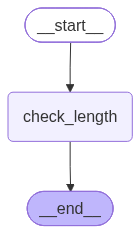

In [12]:
# Sub Graph for topic name validation
from langgraph.graph import StateGraph, START, END

class TopicValidation(TypedDict):
    topic: str
    valid: bool

def check_length(state: TopicValidation) -> dict:
    topic = state['topic']
    if len(topic) < 5:
        state['valid'] = False
    else:
        state['valid'] = True
    return state

topic_validation_graph_builder = StateGraph(TopicValidation)

# Node registration
topic_validation_graph_builder.add_node("check_length", check_length)

# Add edges to nodes
topic_validation_graph_builder.add_edge(START, "check_length")
topic_validation_graph_builder.add_edge("check_length", END)

topic_validation_graph = topic_validation_graph_builder.compile()
print('Topic validation graph is ready')
topic_validation_graph

Blog graph is ready


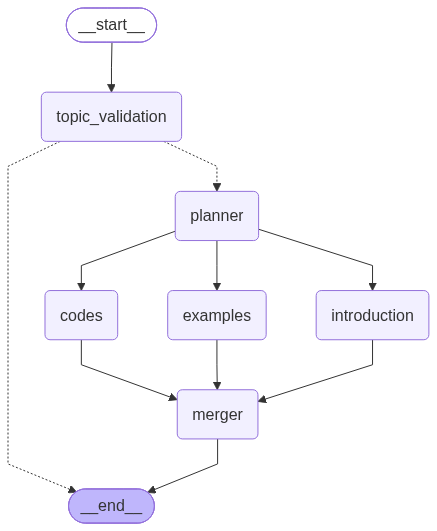

In [13]:
# Graph definition
from langgraph.graph import StateGraph, START, END

blog_graph_builder = StateGraph(BlogState)

# Node registration
blog_graph_builder.add_node("planner", planner_node)
blog_graph_builder.add_node("introduction", introduction_node)
blog_graph_builder.add_node("examples", examples_node)
blog_graph_builder.add_node("codes", codes_node)
blog_graph_builder.add_node("merger", merger_node)
# Every graph can be registered as a valid Node in another graph
blog_graph_builder.add_node("topic_validation", topic_validation_graph)

# Add edges to nodes
blog_graph_builder.add_edge(START, "topic_validation")

blog_graph_builder.add_conditional_edges(
    "topic_validation",
    lambda _state: "planner" if _state['valid'] else END,
    {
        "planner": "planner",
        END: END
    }
)

blog_graph_builder.add_edge("planner", "introduction")
blog_graph_builder.add_edge("planner", "examples")
blog_graph_builder.add_edge("planner", "codes")

blog_graph_builder.add_edge("introduction", "merger")
blog_graph_builder.add_edge("examples", "merger")
blog_graph_builder.add_edge("codes", "merger")

blog_graph_builder.add_edge("merger", END)

blog_graph = blog_graph_builder.compile()
print('Blog graph is ready')
blog_graph

In [15]:
# Call the Blog Graph
response = blog_graph.invoke({
    "topic": "GenAI"
})

response

{'topic': 'GenAI',
 'introduction': 'This is an introduction about GenAI',
 'examples': 'Please find below the examples on the topic GenAI',
 'codes': 'Here are the code snippets on the topic GenAI',
 'final_blog': 'GenAI\nThis is an introduction about GenAI\nPlease find below the examples on the topic GenAI\nHere are the code snippets on the topic GenAI\n',
 'valid': True}